# **Week 8: Central Limit Theorem and Sampling Distributions**

```
.------------------------------------.
|   __  ____  ______  _  ___ _____   |
|  |  \/  \ \/ / __ )/ |/ _ \___  |  |
|  | |\/| |\  /|  _ \| | | | | / /   |
|  | |  | |/  \| |_) | | |_| |/ /    |
|  |_|  |_/_/\_\____/|_|\___//_/     |
'------------------------------------'

```

## **Pre-Configurating the Notebook**

### **Switching to the R Kernel on Colab**

By default, Google Colab uses Python as its programming language. To use R instead, you’ll need to manually switch the kernel by going to **Runtime > Change runtime type**, and selecting R as the kernel. This allows you to run R code in the Colab environment.

However, our notebook is already configured to use R by default. Unless something goes wrong, you shouldn’t need to manually change runtime type.

### **Importing Required Packages**
**Run the following lines of code**:

In [8]:
#Do not modify

setwd("/content")

# Remove `MXB107-Notebooks` if exists,
if (dir.exists("MXB107-Notebooks")) {
  system("rm -rf MXB107-Notebooks")
}

# Fork the repository
system("git clone https://github.com/ArwenNugteren/MXB107-Notebooks")

# Change working directory to "MXB107-Notebooks"
setwd("MXB107-Notebooks")

#
invisible(source("R/preConfigurated.R"))

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr

Loading required package: stringr

Loading required package: magrittr


Attaching package: ‘magrittr’


The following object is masked from ‘package:tidyr’:

    extract


Loading required package: IRdisplay

Loading required package: png

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘png’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: grid

Loading required package: knitr

Loading required package: jpeg

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘jpeg’”
I

**Do not modify the following**

In [9]:
if (!require("testthat")) install.packages("testthat"); library("testthat")

test_that("Test if all packages have been loaded", {

  expect_true(all(c("ggplot2", "tidyr", "dplyr", "stringr", "magrittr", "knitr") %in% loadedNamespaces()))

})

Loading required package: testthat


Attaching package: ‘testthat’


The following objects are masked from ‘package:magrittr’:

    equals, is_less_than, not




Test passed with 1 success 🥳.


# Warm-up activity: Illustrating the CLT
Consider playing Dungeons and Dragons as a wizard, dealing damage based on a combination of D6 rolls where you want to roll high values to deal a lot of damage.

Firstly, by simulating 10,000 dice rolls, plot a histogram of the distribution of the distribution of values. What distribution does this resemble? What's your probability of rolling a 1?

<details>
<summary>▶️ Click to show the solution</summary>

```r
dice <- 1:6

N = 10^5
rolls <- sample(dice, N, replace=T)
hist(rolls, breaks=seq(0.5, 6.5, by=1))

# probability of a 1
sum(rolls == 1)/N
```

</details>

As a wizard, you have access to the 'Burning Hands' spell, which deals damage based on 3 D6 rolls. Plot this distribution and describe the shape. What's the probability of rolling 18 (the highest possible value)?

<details>
<summary>▶️ Click to show the solution</summary>

```r
burning_hands <- replicate(N, sum(sample(dice, 3, replace=TRUE)))
hist(burning_hands)
# the distribution is symmetric and unimodal
# the mean, median and mode all occur around 10

# probability of an 18
sum(burning_hands == 18)/N
```

</details>

As you level up, you gain access to the 'Fireball' spell, which deals 8 D6 of damage. Let's say you consider a "terrible" roll to be a result in the bottom 25% of the range possible values. What's the probability of rolling a value this low given 8 D6's? How does it compare to the normal approximation?

<details>
<summary>▶️ Click to show the solution</summary>

```r
fireball <- replicate(N, sum(sample(dice, 8, replace=TRUE)))
hist(fireball)

# the result of 8 D6's can range from 8 up to 48, a range of 40
# a value in the bottom 25% would be from 8 up to 17
sum(fireball < 18)/N

pnorm(18, mean(fireball), sd(fireball))
# we can see that there is some error in the normal approximation, particularly for uncommon values
```

</details>

At level 9, you can unlock the 'Meteor Swarm' spell, which deals a huge 40 D6 of damage. Plot this distribution. Now what is the probability of a "terrible" roll?

<details>
<summary>▶️ Click to show the solution</summary>

```r
meteor_swarm <- replicate(N, sum(sample(dice, 40, replace=TRUE)))
hist(meteor_swarm)

# the result of 40 D6's can range from 40 up to 240, a range of 200
# a value in the bottom 25% would be from 50 up to 89
sum(meteor_swarm < 90)/N

# you may find that the value is 0! You can try with more simulations, or just accept that is's a really small probability
```

</details>

We can see from the shape of the histograms that the results become more and more like a bell curve, and the probability of extreme rolls (high or low) becomes rarer. Now calculate the probability of a "terrible" roll for 'Meteor Swarm' using the normal distribution approximation.

<details>
<summary>▶️ Click to show the solution</summary>

```r
mean_meteor <- mean(meteor_swarm)
sd_meteor <- sd(meteor_swarm)

pnorm(90, mean_meteor, sd_meteor)

# if you did calculate by simulation before, you should find that the results are pretty similar ...
# or at least that this is a really really small probability!
```

</details>

# Approximating Binomial probabilities

## Question 1
A faculty within a certain University has a quota for an entering class of 800 students for a particular course. Since not all students who are offered a place accept, more than 800 places are offered. Past experience shows that about 70% of students offered a place in this course will accept. The faculty decides to offer places to 1100 students. Assuming the students make their decisions independently and the percentage acceptance is taken as 70%:


a) Give an expression for the probability that the number of students accepting exceeds the class requirements.

b) Use an appropriate distribution to calculate the best approximation for the answer to (a).

<details>
<summary>▶️ Click to show the solution</summary>

a) Let $X$ be the number of students in 1100 who accept a place, then $X \sim \mathrm{Bin}(1100,0.7)$.
				$$Pr(X > 800) = \sum_{x=801}^{1100} \binom{1100}{x} 0.7^x 0.3^{1100 - x}.$$


b)	$\mu = np = 770$ and $\sigma^2 = np(1-p) = 231$. Since $\mu>5$ and $\sigma^2>5$, we can approximate $X$ with a normal distribution. Let $X \approx Y \sim N(770,231)$.
				$$Pr(X > 800) \approx Pr(Y > 800.5) \text{Using continuity correction.}$$
Using R:
```r
pnorm(800.5,770,sqrt(231), lower.tail = FALSE)
# 0.022388
```
So the probability is approximately 0.0224.

Using R, we can compare this estimate to the exact probability:
```r
pbinom(800,1100,0.7, lower.tail = FALSE)
# 0.02164608
```

</details>

## Question 2
Consider a new university policy that 53\% of students are in support of.
Approximate the probability that more than 50\% of a random sample of size $n$ students are in favour of this new policy when:

a) $n = 9$

b) $n = 99$

c) $n = 999$

<details>
<summary>▶️ Click to show the solution</summary>

Let $X_n$ be the number of students in a sample of $n$ students who agree with the new policy.

Then, the expected number of students from the sample that we would expect to agree will be $0.53n$, and the variance will be $0.53\times 0.47\times n$.

We are looking for the probabilities $Pr(X_n\geq 0.5n)$.

Note that $0.53\times 9 = 4.77<5$ and so we will have to use the Poisson approximation. However, $0.53\times 99 =52.47>5$ and so we will be able to use the normal approximation for the last two cases.

All of the probabilities are obtained using R.



a) $n = 9$

Let $X_9 \approx Y_9$, where $Y_{9}\sim Poisson(4.77)$. Then,
				$$
				Pr(Y_{9}> 0.50\times 9) =Pr(Y_9\geq5)\approx 0.5183.
				$$

b) $n = 99$, so that $X_{99}\approx Y_{99}\sim N(52.47,4.966^2)$.
				\begin{align*}
					Pr(X_{99} > 0.5 \times 99) &= Pr(X_{99} > 49.5),\\
						&= Pr(X_{99} \ge 50),\\
						&\approx Pr(Y_{99} > 49.5),\quad \text{Continuity correction},\\
						&\approx 0.7251.
				\end{align*}


c) $n = 999$, so that $X_{999}\approx Y_{999}\sim N(529.47,15.775^2)$.
				\begin{align*}
					Pr(X_{999} > 0.5 \times 999) &= Pr(X_{999} > 499.5),\\
						&= Pr(X_{999} \ge 500),\\
						&\approx Pr(Y_{999} > 499.5),\quad \text{Continuity correction},\\
						&\approx 0.9713.
				\end{align*}

</details>

# CLT for the sample mean









In practice, when the sample size $n$ is sufficiently large, the **CLT approximation** can be applied.
$$
\displaystyle \bar{x} \approx \mathcal{N}\Big(\mu, \frac{\sigma^2}{n}\Big).
$$  

How large $n$ needs to be depends on various factors, such as the **skewness** of the population distribution. A common rule of thumb is that if

$$
n > 25 \times (\text{skewness})^2,
$$

the normal approximation is reasonable (see [Sampling Techniques, 3rd Edition | Wiley](https://www.wiley.com/en-us/Sampling+Techniques%2C+3rd+Edition-p-9780471162407). Here, the **skewness** can be estimated from the data.

Another common rule of thumb is that if

$$
n > 30,
$$

the normal approximation is reasonable. However, it is less precise when data are heavily skewed.

## How large should `n` be for skewed distributions?

First, we will visually demonstrate the CLT for populations with different skewness levels. For each example, we will draw 10,000 samples, and compute the sample mean for each, forming the estimated sampling distribution of the sample mean.

**Squared standard Gaussian**:

[1] "skewness(x)^2*25 = 194.792585668007"


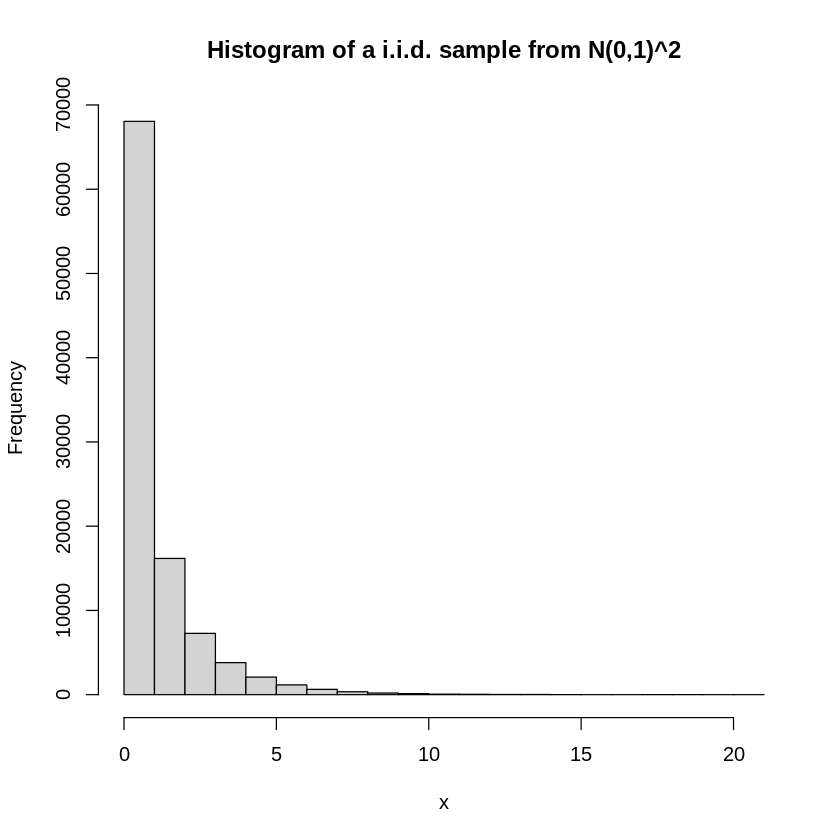

In [13]:
x = rnorm(10^5)^2 #Draw random sample of size 10^5 from N(0,1)^2
print(paste0("skewness(x)^2*25 = ", skewness(x)^2*25))

hist(x, main = "Histogram of a i.i.d. sample from N(0,1)^2")

This suggests that we need a sample size of at least `195`

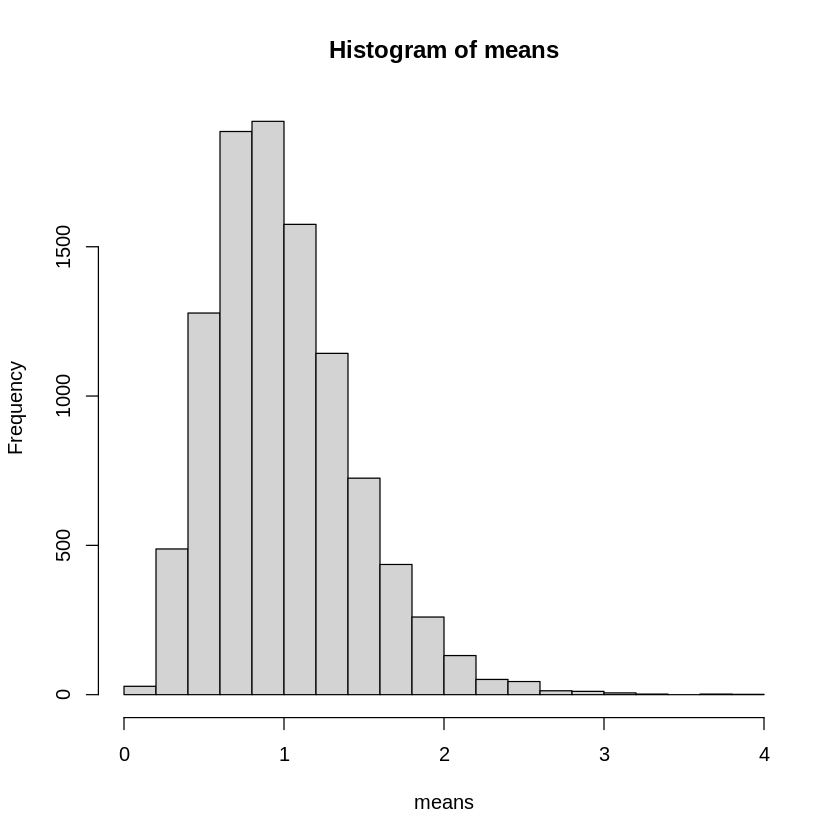

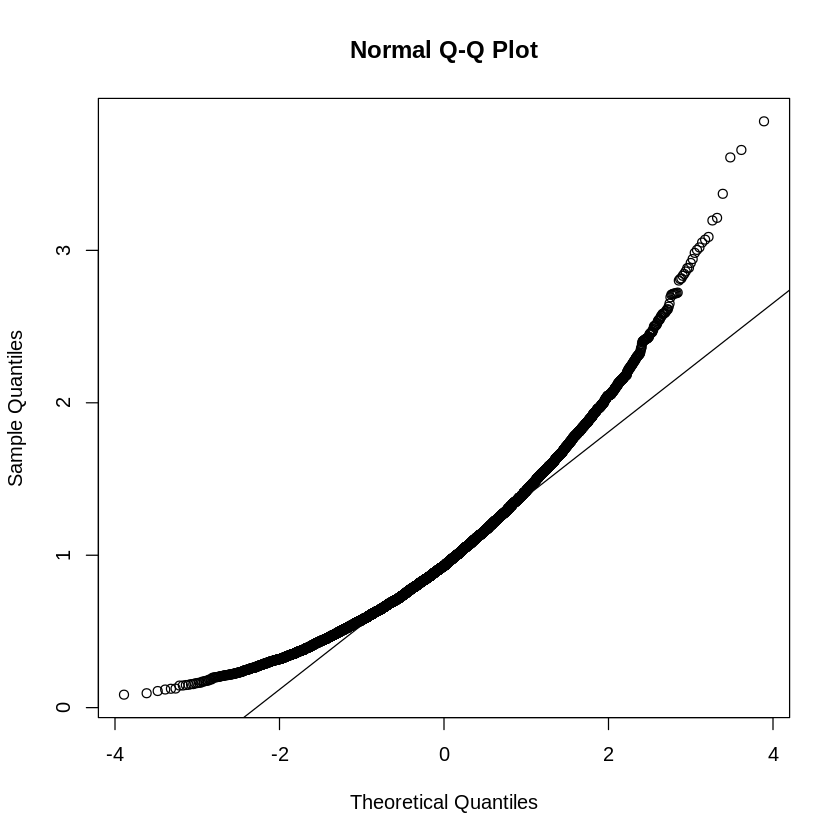

In [24]:
repetitions = 10^4
N = 10

means <- replicate(repetitions, mean(rnorm(N)^2))

hist(means)

# we can plot the quantiles of the data against the standard normal distribution
qqnorm(means)
qqline(means)

In [ ]:
repetitions = 10^4
N = 30

means <- replicate(repetitions, mean(rnorm(N)^2))

hist(means)

# we can plot the quantiles of the data against the standard normal distribution
qqnorm(means)
qqline(means)

In [ ]:
repetitions = 10^4
N = 200

means <- replicate(repetitions, mean(rnorm(N)^2))

hist(means)

# we can plot the quantiles of the data against the standard normal distribution
qqnorm(means)
qqline(means)

**Poisson(3)**

[1] "skewness(x)^2*25 = 8.45605152405053"


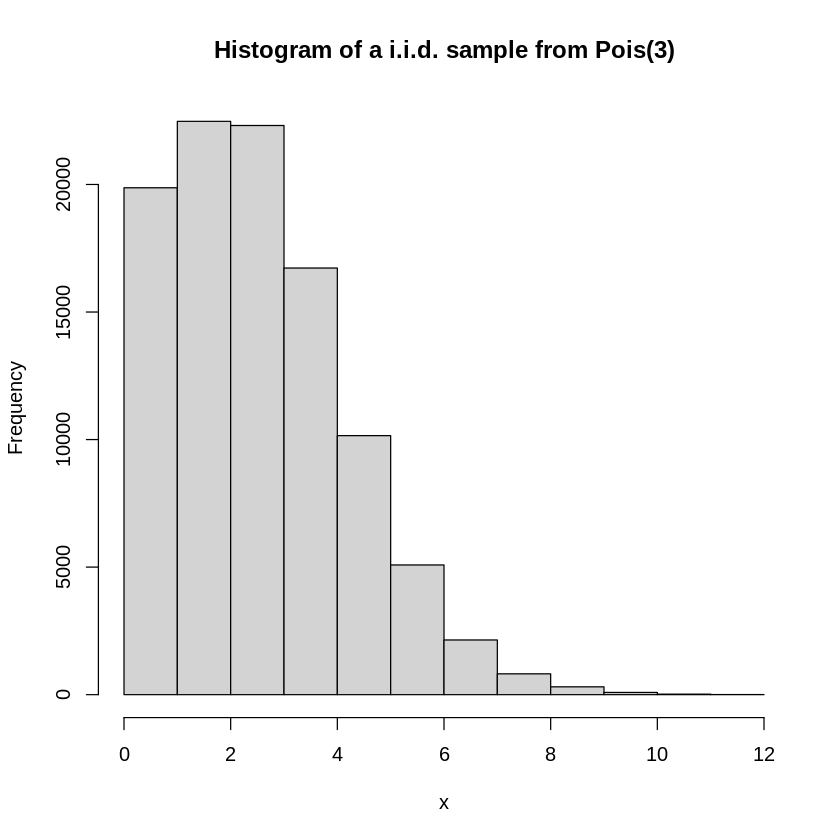

In [25]:
x = rpois(10^5, 3)
print(paste0("skewness(x)^2*25 = ", skewness(x)^2*25))
hist(x, breaks = 15, main = "Histogram of a i.i.d. sample from Pois(3)")

This suggests that we need a sample size of 8 for the CLT to hold.

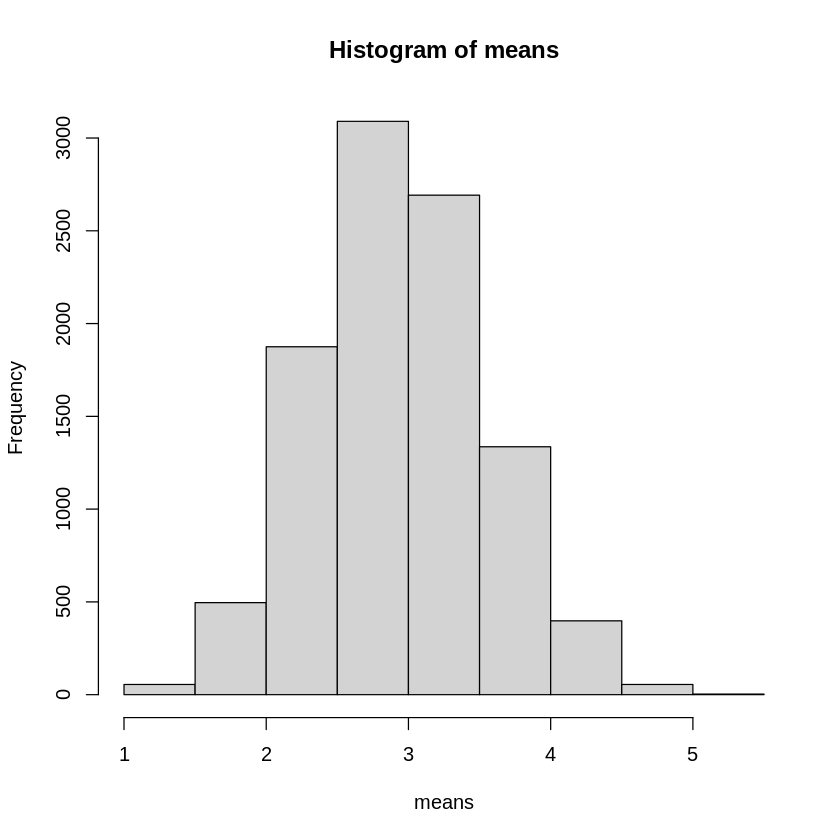

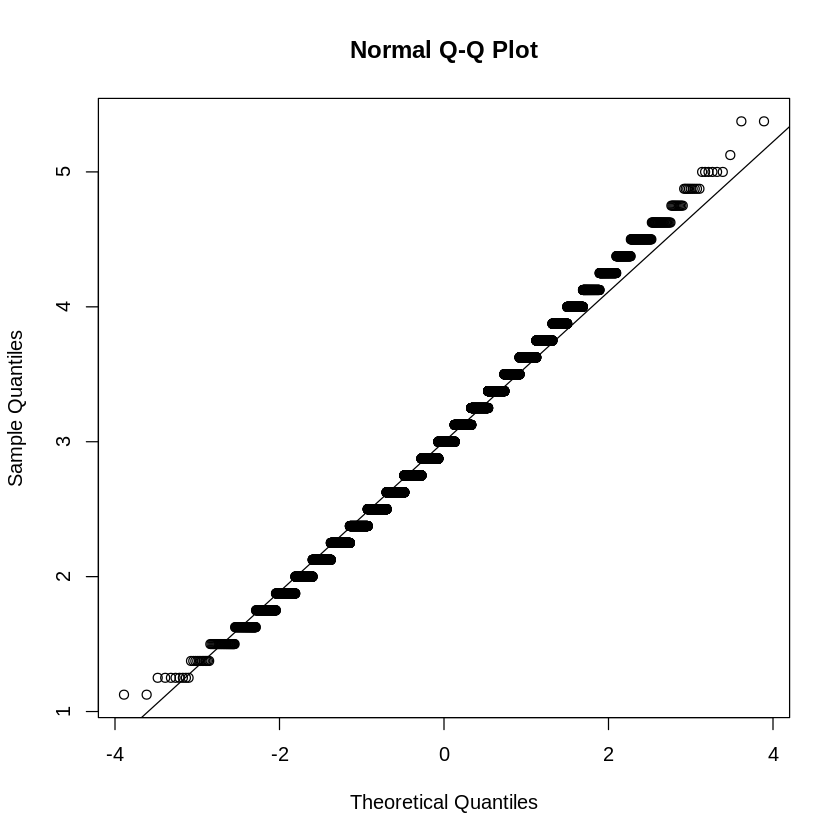

In [26]:
repetitions = 10^4
N = 8

means <- replicate(repetitions, mean(rpois(8,3)))

hist(means)

# we can plot the quantiles of the data against the standard normal distribution
qqnorm(means)
qqline(means)

**Poisson(10)**

[1] "skewness(x)^2*25 = 2.62457652332991"


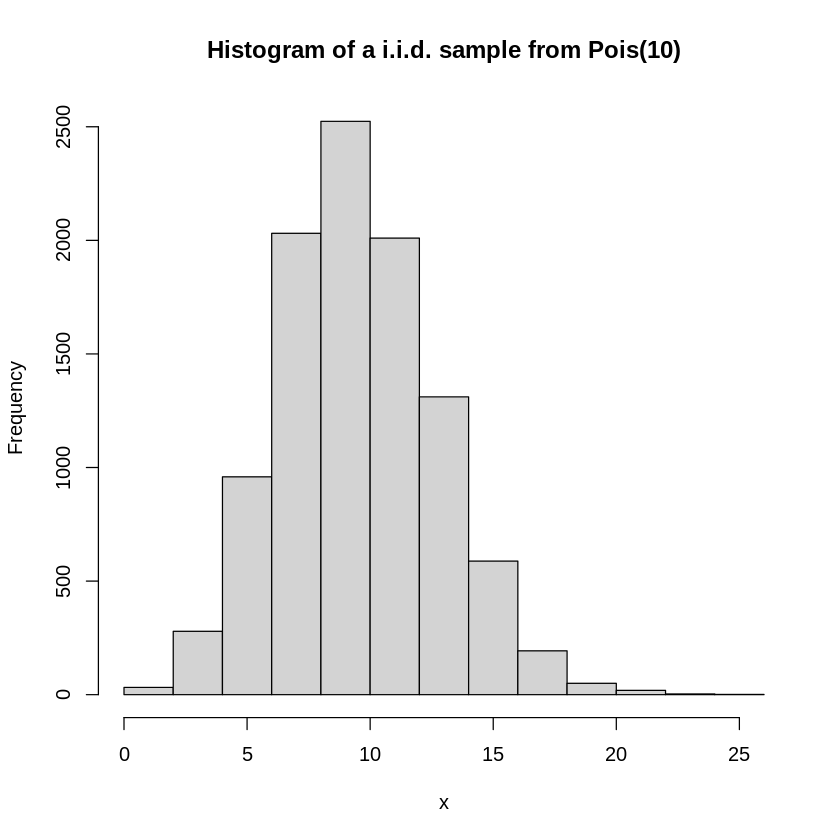

In [27]:
set.seed(1)

x = rpois(10^4, 10)
print(paste0("skewness(x)^2*25 = ", skewness(x)^2*25))
hist(x, breaks = 15,main = "Histogram of a i.i.d. sample from Pois(10)")


This suggests that we only need a sample size of 3 for the CLT to hold!!!

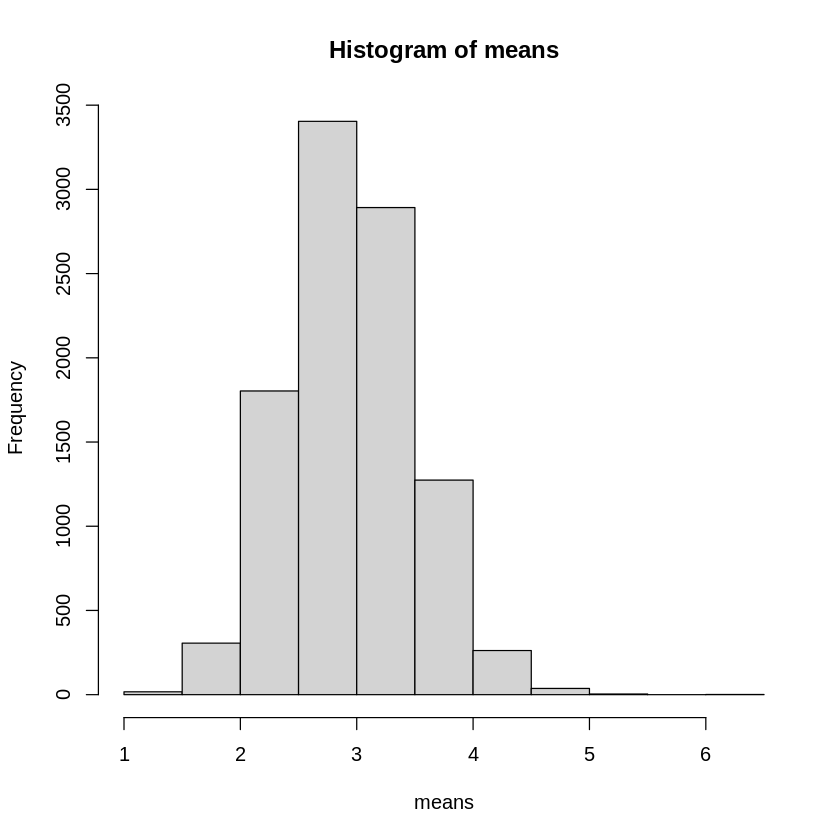

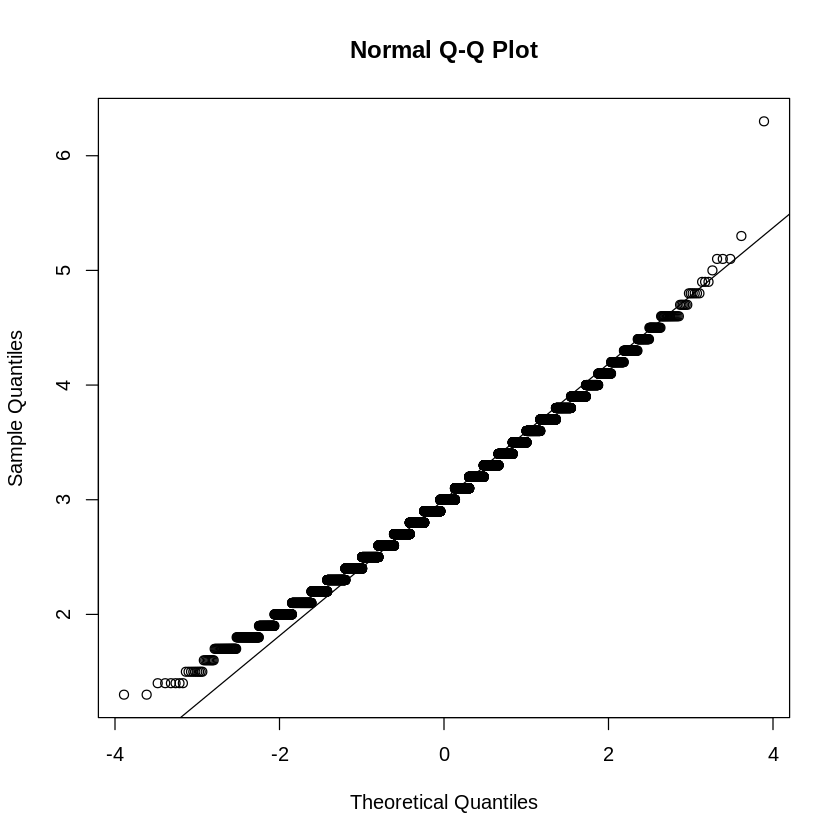

In [28]:
repetitions = 10^4
N = 8

means <- replicate(repetitions, mean(rpois(10,3)))

hist(means)

# we can plot the quantiles of the data against the standard normal distribution
qqnorm(means)
qqline(means)

It is obvious that if the true data-generating process is Gaussian then we only need a sample size of 1 for the CLT to hold (since the average of an iid Gaussian random sample is still Gaussian!).

In [ ]:
set.seed(1)

x = rnorm(10^5)
print(paste0("skewness(x)^2*25 = ", skewness(x)^2*25))
hist(x, breaks = 15, main = "Histogram of a i.i.d. sample from standard Gaussian")

## Question: Estimating the Probability of $a < \bar{x} < b$

A beverage plant calibrates a bottling machine to fill 33 cL bottles, but there is some variability in the process, and from time to time, the machine needs adjustment. Every hour, an employee takes a sample of ten bottles and measures the amount of beverage in each one to monitor the machine. Prior testing shows that the volume of each bottle has a mean of 33 cL and a variance of 0.6 cL. What is the (approximate) probability of observing a sample mean of $\bar{x}\leq 32.7$ cL based on a sample of \(n=10\) bottles?



<details>
<summary>▶️ Click to show the solution</summary>

The sampling distribution of the sample mean $\bar{x}$ is  

$$
\displaystyle
\bar{x} \sim \mathcal{N}\big(\mu, \sigma^2/n\big) \sim \mathcal{N}(33, 0.6/10).
$$

So $\Pr(\bar{x} \le 32.7)$ can be found using the standard normal distribution:  

$$
\displaystyle
\begin{aligned}
\Pr(\bar{x} \le 32.7)
&= \Pr\Bigg(\frac{\bar{x}-\mu}{\sigma/\sqrt{n}} \le \frac{32.7-33}{\sqrt{0.6/10}}\Bigg) \\
&= \Pr(Z \le -1.22) \\
&\approx 0.11.
\end{aligned}
$$

This probability can be calculated using the `pnorm()` function in R.

```r
pnorm(32.7, mean = 33, sd = sqrt(0.6/10))
```

</details>

# Asymptotic Sampling Distribution of Sample Proportion

## Question

Suppose a population has a proportion $p = 0.6$ of people who prefer coffee over tea. We draw an i.i.d. random sample of size $n = 100$ from the population. Let $\hat{p}$ denote the sample proportion.  

By the CLT, for sufficiently large $n$, the sampling distribution of $\hat{p}$ is approximately normal:  

$$
\displaystyle \hat{p} \sim \mathcal{N}\Big(p, \frac{p(1-p)}{n}\Big) = \mathcal{N}\Big(0.6, \frac{0.6 \times 0.4}{100}\Big)
$$
Compute the approximate probability that the sample proportion is between 0.55 and 0.65.



<details>
<summary>▶️ Click to show the solution</summary>


$$
\begin{align}
\displaystyle \Pr(0.55 \le \hat{p} \le 0.65) &= \Pr\left(\frac{0.55-0.6}{\sqrt{0.6 \cdot 0.4 / 100}} \le Z \le \frac{0.65-0.6}{\sqrt{0.6 \cdot 0.4 / 100}}\right) \\
&= \Pr(-1.021 \le Z \le 1.021) \\
&\approx 0.692
\end{align}
$$


We can compute this in **R** using `pnorm()`:

```r
p = 0.6
n = 100
se = sqrt(p*(1-p)/n)

pnorm(0.65, mean = p, sd = se) - pnorm(0.55, mean = p, sd = se)
```

</details>

# Workshop Questions


## Question 1
If 10% of all passengers travelling on a certain airline alter their flight arrangements:

a) Approximate the probability that, among 150 persons travelling on this airline, at least 7 alter their flight arrangements.

b) Find the exact value in R and compare.

<details>
<summary>▶️ Click to show the solution</summary>

a) Let $X$ be the number of passengers (out of 150) that alter their flight arrangements. Then $X \sim \mathrm{Bin}(150,0.1)$. Since both $np > 5$ and $n(1-p) > 5$, we can use a normal approximation.

			\begin{align*}
			\mathbb{E}(X) &= np =  150 \times 0.1 = 15.\\
			\text{Var}(X) &= np(1-p) = 15 \times 0.9 = 13.5.
			\end{align*}

Therefore, $X \approx Y \sim N(np,np(1-p)) = N(15,13.5)$. So
			\begin{align*}
			Pr(X \ge 7) &\approx Pr(Y > 6.5), \: \text{Continuity correction}\\
			&\approx 0.9896.
			\end{align*}
Using R:
```r
pnorm(6.5,15,sqrt(13.5),lower.tail = FALSE)
# 0.9896499
```


b) Note that, using R, we can compare this estimate to the exact probability:

```r
1 - pbinom(6, 150, 0.1)
# 0.9943983
```
We can see that the approximation is less than 0.5% from the true value, so it is quite a good approximation.

</details>

### **Question 2**

An automotive battery producer makes a certain model of battery with an average life of 1110 days with a standard deviation of 80 days. Given a sample of size $n = 40$, find the probability that:

a) The average battery for the sample is between 1100 and 1110 days.

<details>
<summary>▶️ Click to show the solution</summary>

Assuming that $n = 40$ is sufficiently large for the CLT to hold,

$$\begin{align}
\bar{x} &\approx \mathcal(1100, 80^2)\\
n&= 40\\
\mathbb{E}(\bar{x}) &= 1100 \\
\text{Var}(\bar{x}) &= \frac{80^2}{40} = 160
\end{align}
$$


We want to calculate the probability:  

$$
\begin{aligned}
\Pr(1100 < \bar{x} < 1110)
&= \Pr\left( \frac{1100 - \mu}{\sigma/\sqrt{n}} < \frac{\bar{x} - \mu}{\sigma/\sqrt{n}} < \frac{1110 - \mu}{\sigma/\sqrt{n}} \right) \\
&= \Pr\left( \frac{1100 - 1110}{80/\sqrt{40}} < Z < \frac{1110 - 1110}{80/\sqrt{40}} \right) \\
&= \Pr(0 < Z < 0.7905694) \\
&= \Pr(Z < 0.7905694) - Pr(Z < 0)
\end{aligned}
$$

```r
Z <- 10/(80/sqrt(40))
pnorm(Z)-pnorm(0)
# 0.2854023
```

The probability of the average battery life for a given sample being between 1100 and 1100 days is approximately 0.285.
</details>

b) The average battery life for the sample is greater than 1120 days

<details>
<summary>▶️ Click to show the solution</summary>

We want to calculate the probability:  

$$
\begin{aligned}
\Pr(\bar{x} > 1120)
&= \Pr\left(\frac{\bar{x} - \mu}{\sigma/\sqrt{n}} > \frac{1120 - \mu}{\sigma/\sqrt{n}} \right) \\
&= \Pr\left(Z > 1.581139 \right)
\end{aligned}
$$

```r
Z <- (1120-1100)/(80/sqrt(40))
pnorm(Z, lower.tail = FALSE)
```

The probability that the average battery life for a sample is greater than 1120 days is approximately 0.057.

</details>

### **Question 3**


A factory produces light bulbs, and historically, 5% of them are defective. To monitor quality, an inspector randomly selects 150 bulbs each day. Let $\hat{p}$ be the sample proportion of defective bulbs in a daily sample.  


a) Use the CLT, approximate the sampling distribution of $\hat{p}$.  


<details>
<summary>▶️ Click to show the solution</summary>

By the CLT, for sufficiently large $n$, the sampling distribution of $\hat{p}$ is approximately normal:  

$$
\hat{p} \sim N\Big(p, \frac{p(1-p)}{n}\Big) = N\Big(0.05, \frac{0.05 \times 0.95}{150}\Big)
$$


</details>

b) Explain why the CLT approximation is reasonable in this context.

<details>
<summary>▶️ Click to show the solution</summary>

As we have

$$
np = 150\times0.05 = 7.5 > 5,
$$
and
$$
n(1-p) = 150\times0.95 = 142.5 > 5,
$$
the CLT approximation is reasonable.

</details>

c) Compute the probability that the daily sample contains more than 10% defective bulbs.  


<details>
<summary>▶️ Click to show the solution</summary>
We want to compute the probability that the sample proportion exceeds 10%:  

$$
\begin{align}
P(\hat{p} > 0.10) &= P\left(\frac{0.10-0.05}{\sqrt{0.05 \cdot 0.95 / 150}} \le Z\right) \\
&= P(Z > 2.81)
\end{align}
$$

We can compute this in **R** using `pnorm()`:  

```r
Solution will be released at the end of the week!p = 0.05
n = 150
x = 0.10

se = sqrt(p * (1 - p) / n)
pnorm(x, mean = p, sd = se, lower.tail = F)
# 0.002478943
```
The probability that the daily sample contains more than 10% defective bulbs is approximately 0.0025.


</details>

## Question 4
A lecture theater holds a maximum on 150 students. However, the university knows that, on average, only 27% of those enrolled into a unit will attend. In response to this, there is a policy allowing 500 students to enroll for the lecture. Calculate the approximate probability that more than 150 students will attend the lecture.

<details>
<summary>▶️ Click to show the solution</summary>

Let $X$ be the number of students who attend the lecture. Then $X\sim Bin(500,0.27)$.
We want to calculate $Pr(X>150)$.
Since $np = 135>5$ and $n(1-p) = 365>5$, we can use a normal approximation.

Using the Continuity correction, we will calculate $Pr(Y\geq 150.5)$, where $Y\sim N(np,np(1-p))$.
\begin{align*}
	Pr(Y\geq 150.5) &= Pr\left(Y \geq \frac{150.5-500\times 0.27}{\sqrt{500\times 0.27\times 0.73}}\right)\\
  & = Pr( Y \geq 1.561....) \\
		& \approx 0.0592
		\end{align*}
Probabilities calculated in R using
```r
y <- (150.5 - 500*0.27)/sqrt(500*0.27*0.73)
1- pnorm(y)
```
</details>


## Challenge question
Using the knowledge that the sum of independent and identically distributed (iid) geometric random variables forms a negative binomial random variable, use the CLT to build a normal approximation for the negative binomial distribution.

<details>
<summary>▶️ Click to show the solution</summary>

Let $X_1,\,X_2,\,...,\,X_k$ be iid random variables from a geometric distribution with probability of success $p$.  Each $X_i$ represents the number of trials (number of failures) until getting with $i$th success.


Let's start with the number of trials until success, then $X\sim geom(p)$ with $\mu = \mathbb{E}[X] = 1/p$ and $\sigma^2 = \text{Var}[x] = (1-p)/p^2$.


We can then say $Y\sim NB(k,p)$ where $Y = X_1 + X_2 + \cdots + X_k$.


Using the CLT,  $Y\approx W\sim N(k\mu,k\sigma^2)$.


Substituting in our values for $\mu$ and $\sigma^2$, we get $W\sim N(k/p, k(1-p)/p^2)$. This is a normal approximation to the negative binomial distribution with $k$ successes and probability of success $p$ for each individual trial.


If the geometric distributions were counting the number of failures, then we would have an expected value: $\mathbb{E}[X] = (1-p)/p$.


This would modify the expected value of $W$ to be $\mathbb{E}[W] = k(1-p)/p$, and we obtain $W\sim N(k(1-p)/p, k(1-p)/p^2)$.

</details>